### Time to synthesise some data

We want to fit a model based on the Poisson Pseudo Maximum Likelihood method to model the data (this is good for heteroskedastic data)

Then we can use this to compute synthetic trade data (that will lack outliers)


First, a proof-of-concept using Benin:

In [2]:
# First we got to do some imports (I'm just grabbing the ones from 02 for now)
from pathlib import Path
import platform
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Random seed for reproducibility
np.random.seed(42)


df = pd.read_csv("data/ecowas_df_full.csv")

In [3]:
df.columns

Index(['country', 'year', 'disorder_Demonstrations',
       'disorder_Political violence',
       'disorder_Political violence; Demonstrations',
       'disorder_Strategic developments', 'event_Battles',
       'event_Explosions/Remote violence', 'event_Protests', 'event_Riots',
       'event_Strategic developments', 'event_Violence against civilians',
       'perpetrator_Civilians', 'perpetrator_External/Other forces',
       'perpetrator_Identity militia', 'perpetrator_Political militia',
       'perpetrator_Protesters', 'perpetrator_Rebel group',
       'perpetrator_Rioters', 'perpetrator_State forces', 'target_Civilians',
       'target_External/Other forces', 'target_Identity militia',
       'target_Political militia', 'target_Protesters', 'target_Rebel group',
       'target_Rioters', 'target_State forces', 'fatalities', 'iso3_o',
       'iso3_d', 'distw_harmonic', 'distw_arithmetic', 'dist', 'distcap',
       'contig', 'diplo_disagreement', 'comlang_off', 'comlang_ethno',
     

In [4]:
df_benin = df[df["country"] == "Benin"].copy()
# Since we are dealing with least squares, we can log the valid variables to get changes in %, rather than absolute values (also good as trade is heteroskedastic)
# This is the standard when dealing with the Gravity theory of trade
# However, we can not have values that are 0, since that leads to -inf or NaN 

required_cols = ["gdp_o", "gdp_d", "distw_arithmetic", "tradeflow_baci", "contig"]

df_benin = df_benin[required_cols].dropna()
df_benin = df_benin[
    (df_benin["gdp_o"] > 0) &
    (df_benin["gdp_d"] > 0) &
    (df_benin["distw_arithmetic"] > 0) &
    (df_benin["tradeflow_baci"] >= 0)
]


df_benin["ln_gdp_o"] = np.log(df_benin["gdp_o"])
df_benin["ln_gdp_d"] = np.log(df_benin["gdp_d"])
df_benin["ln_distw_arithmetic"] = np.log(df_benin["distw_arithmetic"])

# Variables that are statistically significant here are gdpcap_ppp_o, gdp_o, pop_d
X = sm.add_constant(df_benin[["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig"]])
y = df_benin["tradeflow_baci"]

# We can add a little sanity check here (will be useful in the future python implementation)
assert np.isfinite(X.values).all()
assert np.isfinite(y.values).all()

ppml = sm.GLM(
    y,
    X,
    family=sm.families.Poisson()
)
ppml_results = ppml.fit(cov_type="HC1")

print(ppml_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         tradeflow_baci   No. Observations:                  273
Model:                            GLM   Df Residuals:                      268
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.4268e+06
Date:                Mon, 13 Apr 2026   Deviance:                   1.0851e+07
Time:                        16:14:20   Pearson chi2:                 4.66e+07
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.1279    

In [5]:
# An example from the data above. We can take the coefficient for the "contig" column and use the PPML formula to find the percentile effect of sharing borders
np.exp(0.8216) - 1

# In this case = 1.27 == 127%

np.float64(1.2741355450628644)

The model we would ideally use for synthetic data (In this case tradeflow_baci):

E[BACI | X] = exp(
    β₀ + β₁ ln GDP_o + β₂ ln GDP_d + β₃ ln dist + β₄ contig + γ₁ ln Comtrade_o + γ₂ ln Comtrade_d + γ₃ ln IMF_o + γ₄ ln IMF_d
)

We would only keep the y_variables where they are present


In [ ]:
# We take it step by step. First we want to create a baseline model (that is, using just the β's from above)
# We want it to work for ALL countries
df_work = df.copy()

# We ensure positive values for the gravity variables
gravity_mask = (
    (df_work["gdp_o"] > 0) &
    (df_work["gdp_d"] > 0) &
    (df_work["distw_arithmetic"] > 0)
)

df_work = df_work.loc[gravity_mask].copy()

df_work["ln_gdp_o"] = np.log(df_work["gdp_o"])
df_work["ln_gdp_d"] = np.log(df_work["gdp_d"])
df_work["ln_distw_arithmetic"] = np.log(df_work["distw_arithmetic"])

mask_observations = df_work["tradeflow_baci"].notna()

X_base = sm.add_constant(df_work.loc[mask_observations, ["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig"]])
y_base = df_work.loc[mask_observations, "tradeflow_baci"]

ppml_base = sm.GLM(
    y_base,
    X_base,
    family=sm.families.Poisson()
).fit(cov_type="HC1")

# Then we can predict for all base rows that we have
X_all_base = sm.add_constant(df_work[["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig"]])

mu_base_hat = ppml_base.predict(X_all_base)
df_work["baci_mu_base"] = mu_base_hat



# Now we can add the auxiliary variables
aux_vars = [
    "tradeflow_comtrade_o",
    "tradeflow_comtrade_d",
    "tradeflow_imf_o",
    "tradeflow_imf_d"
]

for v in aux_vars:
    df_work[f"ln_{v}"] = np.where(
        df_work[v] > 0,
        np.log(df_work[v]),
        np.nan
    )


# We have an error - if any of the auxiliary variables have a single positive line but the rest are missing, we will get a line that contains NaNs or infinite values that break the statsmodel
# -> exog can not contain any NaNs or inf, or it breaks!
# Let's first define our augmented variables - Then we update the mask below so that any missing values fails the entire row
aug_vars = ["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig"] + [
    f"ln_{v}" for v in aux_vars
]

# All right! Time to look at the augmented model (where applicable)
mask_aug = (
    df_work["tradeflow_baci"].notna() &
    #df_work[[f"ln_{v}" for v in aux_vars]].notna().any(axis=1)       This is the problematic line. This adds rows, even if there are some unusable values
    np.isfinite(df_work[aug_vars]).all(axis=1)
)



'''
X_aug = sm.add_constant(
    df_work.loc[mask_aug,
                ["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig"] + [f"ln_{v}" for v in aux_vars]
                ]
)
'''
X_aug = sm.add_constant(df_work.loc[mask_aug, aug_vars])

y_aug = df_work.loc[mask_aug, "tradeflow_baci"]

ppml_aug = sm.GLM(
    y_aug,
    X_aug,
    family=sm.families.Poisson()
).fit(cov_type="HC1")

# We predict an augmented mean 
X_all_aug = sm.add_constant(
    df_work[["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig"] + [f"ln_{v}" for v in aux_vars]]
)

mu_aug_hat = ppml_aug.predict(X_all_aug)
# we can save it as a column to use:
df_work["baci_mu_aug"] = mu_aug_hat

# We need to predict which prediction to use (so basically, augmented when possible, otherwise use the baseline)
has_aux = df_work[[f"ln_{v}" for v in aux_vars]].notna().any(axis=1)
df_work["baci_mu_aug_final"] = np.where(
    has_aux,
    df_work["baci_mu_aug"],
    df_work["baci_mu_base"]
)

# Now we can synthesise it once and for all!
missing_baci = df_work["tradeflow_baci"].isna()

df_work.loc[missing_baci, "tradeflow_baci_synth"] = (
    np.random.poisson(df_work.loc[missing_baci, "baci_mu_aug_final"])
)

df_work.loc[~missing_baci, "tradeflow_baci_synth"] = (
    df_work.loc[~missing_baci, "tradeflow_baci"]
)

df_work["baci_source"] = "observed"

df_work.loc[missing_baci & has_aux, "baci_source"] = "imputed_gravity+trade"
df_work.loc[missing_baci & ~has_aux, "baci_source"] = "imputed_gravity_only"

MissingDataError: exog contains inf or nans

In [17]:
df_work

,country,year,disorder_Demonstrations,disorder_Political violence,disorder_Political violence; Demonstrations,disorder_Strategic developments,event_Battles,event_Explosions/Remote violence,event_Protests,event_Riots,...,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_imf_o,tradeflow_imf_d,dyad,combined_trade_baci,ln_gdp_o,ln_gdp_d,ln_distw_arithmetic,baseline_baci
0,Benin,1997,2,0,0,0,0,0,2,0,...,1008.175,551.155,346.086,560.660,BEN_BFA,0.0,14.634542,14.710647,6.633318,11338
1,Benin,1997,2,0,0,0,0,0,2,0,...,2043.770,357.312,1975.433,359.793,BEN_CIV,0.0,14.634542,16.276996,6.632002,13568
2,Benin,1997,2,0,0,0,0,0,2,0,...,1746.969,1207.293,260.079,286.087,BEN_GHA,0.0,14.634542,15.745790,6.028279,14173
3,Benin,1997,2,0,0,0,0,0,2,0,...,5.133,2.074,5.140,2.716,BEN_GIN,0.0,14.634542,15.146236,7.486613,5932
4,Benin,1997,2,0,0,0,0,0,2,0,...,8.580,NaN,25.699,1.274,BEN_GMB,0.0,14.634542,13.596898,7.694393,2747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4545,Togo,2021,21,12,0,1,1,0,17,13,...,NaN,NaN,NaN,NaN,MLI_TGO,0.0,15.945313,16.767486,7.093405,31998
4546,Togo,2021,21,12,0,1,1,0,17,13,...,NaN,NaN,NaN,NaN,NER_TGO,0.0,15.945313,16.520285,6.830874,32050
4547,Togo,2021,21,12,0,1,1,0,17,13,...,NaN,NaN,NaN,NaN,NGA_TGO,0.0,15.945313,19.904050,6.354370,161312
4548,Togo,2021,21,12,0,1,1,0,17,13,...,NaN,NaN,NaN,NaN,SEN_TGO,0.0,15.945313,17.134246,7.715570,28545


In [12]:
# Now we want to create synthetic data from the PPML. We must make a mask where the tradeflow_baci is missing, but we have valid covariates (those being gdp and distw at the moment)
df_benin_full = df[df["country"] == "Benin"].copy()


missing_mask = (
    df_benin_full["tradeflow_baci"].isna() &
    (df_benin_full["gdp_o"] > 0) &
    (df_benin_full["gdp_d"] > 0) &
    (df_benin_full["distw_arithmetic"] > 0)
)

df_benin_missing = df_benin_full.loc[missing_mask].copy()

df_benin_missing["ln_gdp_o"] = np.log(df_benin_missing["gdp_o"])
df_benin_missing["ln_gdp_d"] = np.log(df_benin_missing["gdp_d"])
df_benin_missing["ln_distw_arithmetic"] = np.log(df_benin_missing["distw_arithmetic"])

X_missing = sm.add_constant(
    df_benin_missing[["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig"]]
)

assert np.isfinite(X_missing.values).all()

# After this we can predict mu-hat --->> This is the conditional mean trade flow (so based on these variables, the expected trade) 

mu_hat = ppml_results.predict(X_missing)


# Now we can generate the synthetic trade flows:
synthetic_trade = np.random.poisson(mu_hat)
# PPML assumes Poisson conditional mean
# This preserves zero probability
# This preserves scale heteroskedasticity

df_synthetic = df_benin_full.copy()

df_synthetic.loc[missing_mask, "tradeflow_baci"] = synthetic_trade
df_synthetic.loc[missing_mask, "synthetic_flag"] = 1
df_synthetic.loc[~missing_mask, "synthetic_flag"] = 0


In [13]:
df_synthetic

,country,year,disorder_Demonstrations,disorder_Political violence,disorder_Political violence; Demonstrations,disorder_Strategic developments,event_Battles,event_Explosions/Remote violence,event_Protests,event_Riots,...,gdpcap_ppp_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_imf_o,tradeflow_imf_d,dyad,combined_trade_baci,synthetic_flag
0,Benin,1997,2,0,0,0,0,0,2,0,...,0.733,14749.0,NaN,1008.175,551.155,346.086,560.660,BEN_BFA,0.0,1.0
1,Benin,1997,2,0,0,0,0,0,2,0,...,2.303,11707.0,NaN,2043.770,357.312,1975.433,359.793,BEN_CIV,0.0,1.0
2,Benin,1997,2,0,0,0,0,0,2,0,...,1.619,8041.0,NaN,1746.969,1207.293,260.079,286.087,BEN_GHA,0.0,1.0
3,Benin,1997,2,0,0,0,0,0,2,0,...,0.818,9603.0,NaN,5.133,2.074,5.140,2.716,BEN_GIN,0.0,1.0
4,Benin,1997,2,0,0,0,0,0,2,0,...,1.107,5772.0,NaN,8.580,NaN,25.699,1.274,BEN_GMB,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,Benin,2021,46,101,1,16,18,1,20,79,...,1.310,37255.0,NaN,NaN,NaN,NaN,NaN,BEN_NER,0.0,1.0
321,Benin,2021,46,101,1,16,18,1,20,79,...,5.459,114693.0,NaN,NaN,NaN,NaN,NaN,BEN_NGA,0.0,1.0
322,Benin,2021,46,101,1,16,18,1,20,79,...,3.769,27376.0,NaN,NaN,NaN,NaN,NaN,BEN_SEN,0.0,1.0
323,Benin,2021,46,101,1,16,18,1,20,79,...,1.816,12471.0,NaN,NaN,NaN,NaN,NaN,BEN_SLE,0.0,1.0


In [19]:
df_synthetic.groupby("synthetic_flag")["tradeflow_baci"].describe()

,count,mean,std,min,25%,50%,75%,max
synthetic_flag,,,,,,,,
0.0,273.0,20044.154733,56107.922720,0.207,205.145,5266.101,17758.516,692453.819
1.0,52.0,12868.692308,16987.338461,3329.000,5082.000,7286.500,12058.750,114276.000


In [23]:
observed_mask = df_benin["tradeflow_baci"].notna()

mu_obs = ppml_results.predict(
    sm.add_constant(
        df_benin.loc[observed_mask, ["ln_gdp_o", "ln_gdp_d", "ln_distw_arithmetic", "contig"]]
    )
)

pd.DataFrame({
    "observed": df_benin.loc[observed_mask, "tradeflow_baci"],
    "predicted": mu_obs
}).corr()

,observed,predicted
observed,1.000000,0.369878
predicted,0.369878,1.000000


In [15]:
synthetic_trade

array([ 14749,  11707,   8041,   9603,   5772,   3651,   3493,   7438,
        13399,  35357,   5444,   8607,   3415,   3530,   5003,   4238,
         4307,   4868,   5389,   4332,   4400,   4369,   4346,   6405,
         5193,   7023,   5328,   5063,   6540,   9307,   6344,   6535,
         6813,   6800,   6986,   7563,   7259,  12179,   8724,  40588,
        28531,  26032,  20654,  10192,   9166,  11389,  20250,  37255,
       114693,  27376,  12471,  20965], dtype=int32)

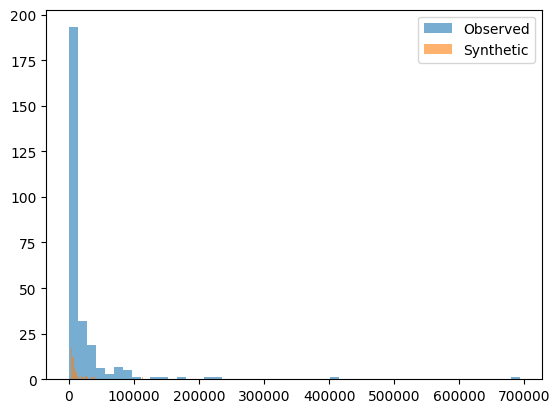

In [27]:

plt.hist(
    df_synthetic.loc[~missing_mask, "tradeflow_baci"],
    bins=50, alpha=0.6, label="Observed"
)
plt.hist(
    df_synthetic.loc[missing_mask, "tradeflow_baci"],
    bins=50, alpha=0.6, label="Synthetic"
)
plt.legend()
plt.show()